In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py
import time
import nibabel as nib

import importlib as imp
import sys
sys.path.append('/ifshome/abenneck/docs_public/yolo_model/docs/scripts')

import yolo_tiles
imp.reload(yolo_tiles)
from yolo_tiles import img_to_tiles, apply_model_to_tiles, load_test_image, preprocess, tileDataset, remove_bbox_in_overlap

import yolo_help
imp.reload(yolo_help)
from yolo_help import bbox_to_rectangles, imshow, convert_data, Net, get_best_bounding_box_per_cell

import yolo_post_help
imp.reload(yolo_post_help)
from yolo_post_help import remove_low_conf_bboxes, postprocess, bb_to_rec

import yolo_help_3D
imp.reload(yolo_help_3D)
from yolo_help_3D import apply_model_to_orthogonal_slices, gen_3D_GT, recon_down, vol_to_mip_rgb, orthogonal_to_3D, vol_to_mip

import yolo_avg_prec
imp.reload(yolo_avg_prec)
from yolo_avg_prec import get_AP, gt_bbox_to_pred_bbox_format, IOU_3D, yolo_output_to_list

### Load the original volume

In [3]:
raw_image_file_first_two_views = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_chunk32.h5'
vol = h5py.File(raw_image_file_first_two_views)
vol['stack'].shape

(3600, 8587, 7321)

# (0) Extract a cube (s=1024) + downsample via avg-pooling

### Extract cube 2,5,3 (s=1024)

In [3]:
cube_i, cube_j, cube_k = 2,5,3
s = 1024

start_i = cube_i*s
start_j = cube_j*s
start_k = cube_k*s

end_i = min((cube_i+1)*s, vol['stack'].shape[0])
end_j = min((cube_j+1)*s, vol['stack'].shape[1])
end_k = min((cube_k+1)*s, vol['stack'].shape[2])

sub_vol = vol['stack'][start_i:end_i, start_j:end_j,start_k:end_k]
sub_vol.shape

(1024, 1024, 1024)

### Apply avg pooling in 4x4 neighborhoods

In [4]:
ds_factor = 4
sub_vol_down = np.zeros([int(sub_vol.shape[0]/ds_factor), int(sub_vol.shape[1]/ds_factor), int(sub_vol.shape[2]/ds_factor)])
sub_vol_down.shape

for i in range(sub_vol_down.shape[0]):
    start = time.time()
    for j in range(sub_vol_down.shape[1]):
        for k in range(sub_vol_down.shape[2]):
            i_start, i_end = i*ds_factor, (i+1)*ds_factor
            j_start, j_end = j*ds_factor, (j+1)*ds_factor
            k_start, k_end = k*ds_factor, (k+1)*ds_factor
            local_region = sub_vol[i_start:i_end, j_start:j_end, k_start:k_end]
            avg_val = round(np.mean(local_region.ravel()))
            sub_vol_down[i,j,k] = avg_val
    print(f'Finished slice {i} in {time.time()-start:.2f}s')

if False:
    # Define affine transform (assume voxel coordinates = world coordinates)
    affine = np.eye(4)
    
    # Create NIfTI image
    vol_out = nib.Nifti1Image(sub_vol_down, affine)
    
    # Save to disk
    outdir = '/ifshome/abenneck/docs_public/misc_outputs'
    out_fname = f'avg_pool_cube_i{cube_i:04d}_j{cube_j:04d}_k{cube_k:04d}.nii.gz'
    nib.save(vol_out, os.path.join(outdir, out_fname))

Finished slice 0 in 0.75s
Finished slice 1 in 0.79s
Finished slice 2 in 0.78s
Finished slice 3 in 0.77s
Finished slice 4 in 0.78s
Finished slice 5 in 0.77s
Finished slice 6 in 0.78s
Finished slice 7 in 0.83s
Finished slice 8 in 0.81s
Finished slice 9 in 0.81s
Finished slice 10 in 0.80s
Finished slice 11 in 0.77s
Finished slice 12 in 0.74s
Finished slice 13 in 0.75s
Finished slice 14 in 0.79s
Finished slice 15 in 0.79s
Finished slice 16 in 0.81s
Finished slice 17 in 0.82s
Finished slice 18 in 0.80s
Finished slice 19 in 0.79s
Finished slice 20 in 0.76s
Finished slice 21 in 0.65s
Finished slice 22 in 0.63s
Finished slice 23 in 0.64s
Finished slice 24 in 0.64s
Finished slice 25 in 0.65s
Finished slice 26 in 0.65s
Finished slice 27 in 0.65s
Finished slice 28 in 0.60s
Finished slice 29 in 0.66s
Finished slice 30 in 0.66s
Finished slice 31 in 0.61s
Finished slice 32 in 0.65s
Finished slice 33 in 0.68s
Finished slice 34 in 0.65s
Finished slice 35 in 0.65s
Finished slice 36 in 0.67s
Finished sl

### Compare the original image with the avgpool version

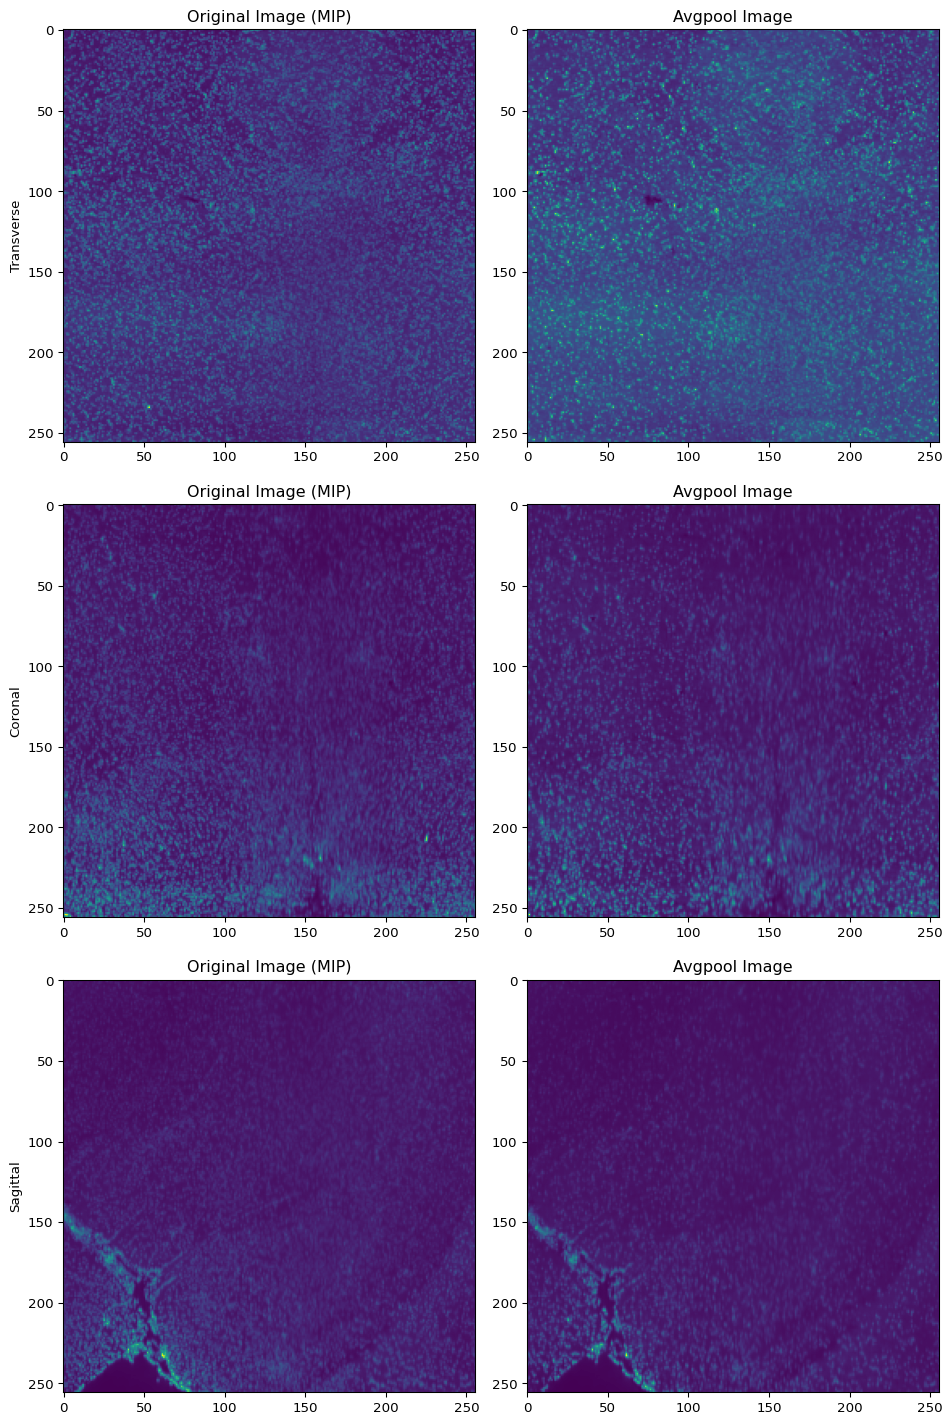

In [7]:
indir = '/ifshome/abenneck/docs_public/misc_outputs'
cube_i, cube_j, cube_k = 2,5,3
data_fname = f'avg_pool_cube_i{cube_i:04d}_j{cube_j:04d}_k{cube_k:04d}.nii.gz'
sub_vol = nib.load(os.path.join(indir, data_fname)).get_fdata()

orig_idx0 = sub_vol.shape[0] // 2
orig_idx1 = sub_vol.shape[1] // 2
orig_idx2 = sub_vol.shape[2] // 2

down_idx0 = sub_vol_down.shape[0] // 2
down_idx1 = sub_vol_down.shape[1] // 2
down_idx2 = sub_vol_down.shape[2] // 2

sub_vol_mip0 = vol_to_mip(sub_vol, 0, ds_factor = 4, slice_idx = orig_idx0)
sub_vol_mip1 = vol_to_mip(sub_vol, 1, ds_factor = 4, slice_idx = orig_idx1)
sub_vol_mip2 = vol_to_mip(sub_vol, 2, ds_factor = 4, slice_idx = orig_idx2)

fig, axs = plt.subplots(3,2, layout='tight')

axs[0,0].imshow(sub_vol_mip0)
axs[0,0].set_ylabel('Transverse')
axs[0,1].imshow(sub_vol_down[down_idx0,:,:])
axs[0,0].set_title('Original Image (MIP)')
axs[0,1].set_title('Avgpool Image')

axs[1,0].imshow(sub_vol_mip1)
axs[1,0].set_ylabel('Coronal')
axs[1,1].imshow(sub_vol_down[:,down_idx1,:])
axs[1,0].set_title('Original Image (MIP)')
axs[1,1].set_title('Avgpool Image')

axs[2,0].imshow(sub_vol_mip2)
axs[2,0].set_ylabel('Sagittal')
axs[2,1].imshow(sub_vol_down[:,:,down_idx2])
axs[2,0].set_title('Original Image (MIP)')
axs[2,1].set_title('Avgpool Image')

fig.set_size_inches(10,15)

# (1) Extract a cube from the original image (d=256)

In [23]:
cube_i, cube_j, cube_k = 2,5,3
s = 1024
d = 256

start_i = cube_i*s
start_j = cube_j*s
start_k = cube_k*s

end_i = min(cube_i * s + d, vol['stack'].shape[0])
end_j = min(cube_j * s + d, vol['stack'].shape[1])
end_k = min(cube_k * s + d, vol['stack'].shape[2])

sub_vol = vol['stack'][start_i:end_i, start_j:end_j,start_k:end_k]

if False:
    # Define affine transform (assume voxel coordinates = world coordinates)
    affine = np.eye(4)
    
    # Create NIfTI image
    vol_out = nib.Nifti1Image(sub_vol, affine)
    
    # Save to disk
    outdir = '/ifshome/abenneck/docs_public/misc_outputs'
    out_fname = f'cube_i{cube_i:04d}_j{cube_j:04d}_k{cube_k:04d}.nii.gz'
    nib.save(vol_out, os.path.join(outdir, out_fname))

### Create a 0-mask, and set the central cube (s=64) to 1

In [26]:
mask_out = np.zeros(sub_vol.shape)
inner_shape = [int(i) for i in (np.array(sub_vol.shape) / 4)]
mask_inner = np.ones(inner_shape)
mask_out[96:160,96:160,96:160] = mask_inner

if False:
    # Define affine transform (assume voxel coordinates = world coordinates)
    affine = np.eye(4)
    
    # Create NIfTI image
    vol_out = nib.Nifti1Image(mask_out, affine)
    
    # Save to disk
    outdir = '/ifshome/abenneck/docs_public/misc_outputs'
    out_fname = f'mask{inner_shape[0]}_i{cube_i:04d}_j{cube_j:04d}_k{cube_k:04d}.nii.gz'
    nib.save(vol_out, os.path.join(outdir, out_fname))

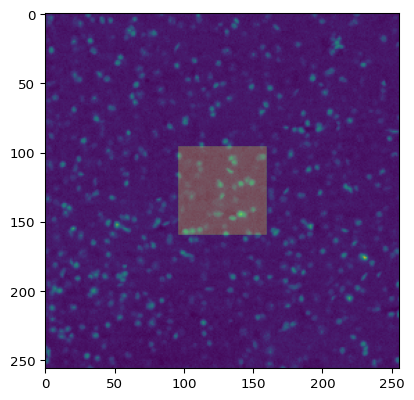

In [27]:
fig, ax = plt.subplots()

ax.imshow(sub_vol[128,:,:])
ax.imshow(mask_out[128,:,:], alpha = 0.25)

# (2) Load the annotated GT mask and convert it into a list of bboxes

In [2]:
# Load the GT annotation
mask_path = '/ifshome/abenneck/docs_public/yolo_model/docs/inputs/mask64_i0002_j0005_k0003_annotated.nii.gz'
mask = nib.load(mask_path)

# 0: Bg, 1: Annotated bg, 2+: Cell ID
gt_bb = []
vals_to_skip = [0, 1]
for val in np.unique(mask.get_fdata()):
    if val in vals_to_skip:
        continue
    mask_cell = np.copy(mask.get_fdata())
    mask_cell[mask_cell != val] = 0.0
    mask_cell[mask_cell == val] = 1.0
    # print(f'Cell {val} volume of {np.sum(mask_cell)} voxels')
    all_x, all_y, all_z = np.where(mask_cell == 1.0)
    gt_bb.append([min(all_x).item(), max(all_x).item(), min(all_y).item(), max(all_y).item(), min(all_z).item(), max(all_z).item(), int(val)])

print(f'{len(gt_bb)} cells in the volume')

276 cells in the volume


### Visualize the boxes

In [3]:
def bb_slice_filter(all_bb, ax_idx, slice_val):
    bb_out = []
    for bb in all_bb:
        if ax_idx == 0 and bb[0] <= slice_val and bb[1] >= slice_val:
            bb_out.append(bb)
        elif ax_idx == 1 and bb[2] <= slice_val and bb[3] >= slice_val:
            bb_out.append(bb)
        elif ax_idx == 2 and bb[4] <= slice_val and bb[5] >= slice_val:
            bb_out.append(bb)
        else:
            continue
    return np.stack(bb_out, axis=0)

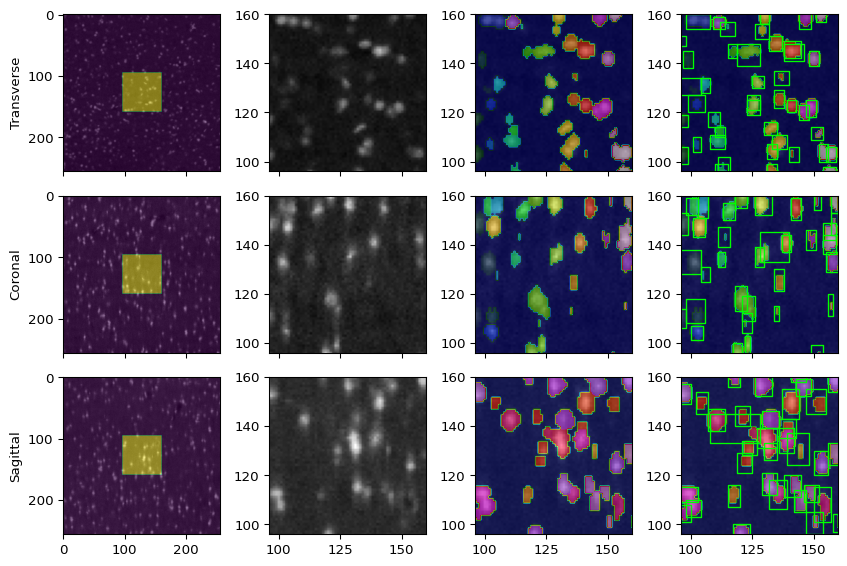

In [4]:
img_path = '/ifshome/abenneck/docs_public/misc_outputs/gt_data/cube_i0002_j0005_k0003.nii.gz'
img = nib.load(img_path)
img = img.get_fdata()

img0 = img[img.shape[0]//2,:,:]
img1 = img[:,img.shape[1]//2,:]
img2 = img[:,:,img.shape[2]//2]

mask_path = '/ifshome/abenneck/docs_public/yolo_model/docs/inputs/mask64_i0002_j0005_k0003_annotated.nii.gz'
mask = nib.load(mask_path)
mask = mask.get_fdata()

mask0 = mask[mask.shape[0]//2,:,:]
mask1 = mask[:,mask.shape[1]//2,:]
mask2 = mask[:,:,mask.shape[2]//2]

boundary_mask_path = '/ifshome/abenneck/docs_public/misc_outputs/gt_data/mask64_i0002_j0005_k0003.nii.gz'
boundary_mask = nib.load(boundary_mask_path)
boundary_mask = boundary_mask.get_fdata()

boundary_mask0 = boundary_mask[boundary_mask.shape[0]//2,:,:]
boundary_mask1 = boundary_mask[:,boundary_mask.shape[1]//2,:]
boundary_mask2 = boundary_mask[:,:,boundary_mask.shape[2]//2]

lim = [96,160]

fig, axs = plt.subplots(3, 4, layout='tight', sharex='col')
axs[0,0].imshow(img0, cmap = 'gray')
axs[0,0].imshow(boundary_mask0, alpha = 0.5)
axs[0,1].imshow(img0, cmap = 'gray')
axs[0,2].imshow(img0, cmap = 'gray')
axs[0,2].imshow(mask0, cmap = 'gist_ncar', alpha = 0.5)
axs[0,3].imshow(img0, cmap = 'gray')
axs[0,3].imshow(mask0, cmap = 'gist_ncar', alpha = 0.5)
bb_plot = bb_to_rec(bb_slice_filter(gt_bb, 0, img.shape[0]//2), pos = [4, 2, 5, 3], fc='none', ec='lime')
axs[0,3].add_collection(bb_plot)
axs[0,0].set_ylabel('Transverse')

axs[1,0].imshow(img1, cmap = 'gray')
axs[1,0].imshow(boundary_mask1, alpha = 0.5)
axs[1,1].imshow(img1, cmap = 'gray')
axs[1,2].imshow(img1, cmap = 'gray')
axs[1,2].imshow(mask1, cmap = 'gist_ncar', alpha = 0.5)
axs[1,3].imshow(img1, cmap = 'gray')
axs[1,3].imshow(mask1, cmap = 'gist_ncar', alpha = 0.5)
bb_plot = bb_to_rec(bb_slice_filter(gt_bb, 1, img.shape[1]//2), pos = [4, 0, 5, 1], fc='none', ec='lime')
axs[1,3].add_collection(bb_plot)
axs[1,0].set_ylabel('Coronal')

axs[2,0].imshow(img2, cmap = 'gray')
axs[2,0].imshow(boundary_mask2, alpha = 0.5)
axs[2,1].imshow(img2, cmap = 'gray')
axs[2,2].imshow(img2, cmap = 'gray')
axs[2,2].imshow(mask2, cmap = 'gist_ncar', alpha = 0.5)
axs[2,3].imshow(img2, cmap = 'gray')
axs[2,3].imshow(mask2, cmap = 'gist_ncar', alpha = 0.5)
bb_plot = bb_to_rec(bb_slice_filter(gt_bb, 2, img.shape[2]//2), pos = [2, 0, 3, 1], fc='none', ec='lime')
axs[2,3].add_collection(bb_plot)
axs[2,0].set_ylabel('Sagittal')

for ax in axs:
    for ax_i in ax[1:]:
        ax_i.set_xlim(lim)
        ax_i.set_ylim(lim)

fig.set_size_inches(9,6)

In [9]:
bb_slice_filter(gt_bb, 1, img.shape[1]//2)

array([[106, 114, 124, 130,  95,  98,   4],
       [128, 138, 127, 134,  95, 104,   6],
       [144, 153, 126, 132,  95,  99,   8],
       [108, 118, 120, 129,  98, 106,  21],
       [101, 107, 122, 130, 100, 105,  33],
       [151, 161, 126, 132, 103, 107,  44],
       [125, 131, 128, 134, 104, 108,  48],
       [131, 137, 125, 131, 111, 114,  75],
       [139, 147, 121, 128, 111, 116,  76],
       [150, 157, 126, 131, 113, 118,  85],
       [113, 123, 125, 132, 118, 123, 103],
       [109, 119, 127, 134, 121, 126, 104],
       [ 92, 100, 126, 131, 117, 121, 105],
       [155, 166, 125, 131, 118, 123, 107],
       [104, 112, 122, 128, 121, 125, 111],
       [ 95, 103, 122, 130, 122, 124, 116],
       [131, 139, 127, 135, 126, 130, 128],
       [133, 145, 108, 128, 128, 140, 129],
       [152, 161, 126, 133, 126, 133, 140],
       [109, 115, 124, 128, 134, 136, 175],
       [121, 130, 122, 129, 134, 138, 177],
       [137, 144, 125, 132, 137, 141, 180],
       [150, 159, 124, 130, 141,